Clasificador de jugadores de baloncesto
Objetivo del ejercicio:

Tu misión es construir un modelo inteligente que clasifique a jugadores de baloncesto según su rendimiento en tres categorías: "Bajo", "Medio" y "Alto", utilizando para ello sus características físicas y estadísticas de juego.

Usarás el algoritmo de árboles de decisión junto con NumPy, pandas, matplotlib y scikit-learn.



🎯 Contexto del problema

Un equipo de baloncesto ficticio está evaluando a nuevos jugadores y necesita una herramienta que, a partir de la altura, el peso y el promedio de puntos por partido, determine automáticamente el nivel de rendimiento del jugador.

Esta herramienta será clave para seleccionar a los mejores candidatos.



🧱 Estructura sugerida de la solución

1. BasketballPlayer

Una clase que representa a cada jugador. Sus atributos son:

height (int): altura en centímetros.

weight (int): peso en kilogramos.

avg_points (float): promedio de puntos por partido.

performance (str): nivel de rendimiento, con valores "Bajo", "Medio" o "Alto".

Método útil:

to_vector(): devuelve [height, weight, avg_points] para ser usado por el modelo.



2. BasketballDataGenerator

Una clase que genera datos sintéticos simulando jugadores reales.

Constructor

__init__(self, num_samples=200)

num_samples: número total de jugadores a generar (por defecto: 200).

Método clave:

generate(): devuelve una lista de objetos BasketballPlayer.

Cada jugador se genera con las siguientes características:

Altura (height): generada con una distribución normal de media 190 cm y desviación estándar 10 cm:

heights = np.random.normal(190, 10, self.num_samples)

Peso (weight): generada con una distribución normal de media 85 kg y desviación estándar 10 kg:

Promedio de puntos por partido (avg_points): generada con una distribución normal de media 10 puntos y desviación estándar 5:

El rendimiento del jugador se asigna de acuerdo al valor del promedio de puntos:

Menos de 8 puntos → "Bajo"

Entre 8 y 15 puntos → "Medio"

Más de 15 puntos → "Alto"



3. BasketballPerformanceClassifier

Encapsula el modelo de árbol de decisión. Métodos clave:

fit(players): entrena el modelo con una lista de jugadores.

predict(height, weight, avg_points): predice el rendimiento de un nuevo jugador.

evaluate(players): imprime la matriz de confusión y el informe de clasificación sobre un conjunto de prueba.



4. BasketballPredictionExample

Contiene el flujo principal:

Generar datos.

Dividirlos en entrenamiento y prueba.

Entrenar y evaluar el clasificador.

Hacer una predicción para un nuevo jugador (por ejemplo: altura = 198 cm, peso = 92 kg, puntos = 17).

Visualizar los jugadores usando matplotlib, diferenciando el rendimiento por colores.



📊 Visualización esperada

Un gráfico de dispersión donde cada punto representa un jugador.

El eje X muestra la altura y el eje Y el promedio de puntos.

El color indica el rendimiento:

🔴 Bajo

🟠 Medio

🟢 Alto

Además:

Se debe marcar la posición del jugador nuevo (por ejemplo, con una estrella ⭐ o un punto grande en azul).



✅ Requisitos técnicos

Usa NumPy para generar datos aleatorios.

Usa pandas para crear el DataFrame de visualización.

Usa DecisionTreeClassifier de sklearn.tree.

Representa visualmente los datos con matplotlib.



🧪 Ejemplo de uso

example = BasketballPredictionExample()
example.run()


Salida esperada

Confusion Matrix:
[[10  0  0]
 [ 0 23  0]
 [ 0  0 27]]
 
Classification Report:
              precision    recall  f1-score   support
 
        Alto       1.00      1.00      1.00        10
        Bajo       1.00      1.00      1.00        23
       Medio       1.00      1.00      1.00        27
 
    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60
 
 
🎯 Predicción personalizada → Altura: 198 cm, Peso: 92 kg, Prom. puntos: 17
   → Categoría predicha: Alto

























Practicar con numpy para generar datos, arboles de decision para realizar clasificaciones de jugadores, y pandas con matplotlib para graficar los resultados obtenidos.


# Solucion:

🏀 Iniciando sistema de scouting de baloncesto con IA...

✅ Modelo entrenado con 140 jugadores.

Confusion Matrix:
[[ 9  0  0]
 [ 0 24  0]
 [ 0  1 26]]

Classification Report:
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00         9
        Bajo       0.96      1.00      0.98        24
       Medio       1.00      0.96      0.98        27

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60

🎯 Predicción personalizada → Altura: 198 cm, Peso: 92 kg, Prom. puntos: 17
   → Categoría predicha: Alto


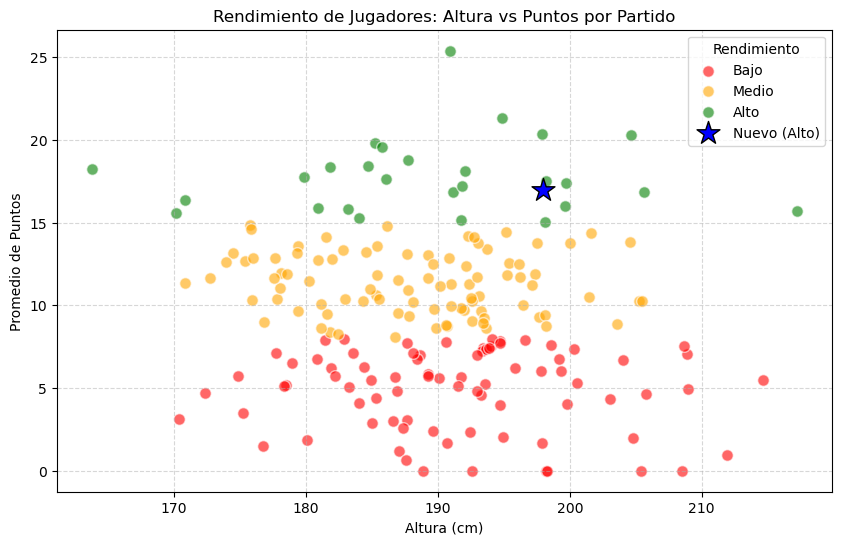

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


class BasketballPlayer:
    
    def __init__(self, height, weight, avg_points, performance=None):
        self.height = height
        self.weight = weight
        self.avg_points = avg_points
        self.performance = performance

    def to_vector(self):
        
        return [self.height, self.weight, self.avg_points]

    def __repr__(self):
        return f"Player(H:{self.height:.0f}cm, W:{self.weight:.0f}kg, P:{self.avg_points:.1f} -> {self.performance})"



class BasketballDataGenerator:
    
    def __init__(self, num_samples=200):
        self.num_samples = num_samples

    def generate(self):
        np.random.seed(42) 
        
        heights = np.random.normal(190, 10, self.num_samples)
        weights = np.random.normal(85, 10, self.num_samples)
        points = np.random.normal(10, 5, self.num_samples)
        
        players = []
        for h, w, p in zip(heights, weights, points):
            
            p = max(0, p) 
            
            
            if p < 8:
                perf = "Bajo"
            elif 8 <= p <= 15:
                perf = "Medio"
            else:
                perf = "Alto"
            
            players.append(BasketballPlayer(h, w, p, perf))
            
        return players



class BasketballPerformanceClassifier:
    
    def __init__(self):
        self.model = DecisionTreeClassifier(random_state=42)

    def _prepare_data(self, players):
        
        X = np.array([p.to_vector() for p in players])
        y = np.array([p.performance for p in players])
        return X, y

    def fit(self, players):
        X, y = self._prepare_data(players)
        self.model.fit(X, y)
        print(f"✅ Modelo entrenado con {len(players)} jugadores.")

    def predict(self, height, weight, avg_points):
        
        prediction = self.model.predict([[height, weight, avg_points]])
        return prediction[0]

    def evaluate(self, players):
        X_test, y_test = self._prepare_data(players)
        y_pred = self.model.predict(X_test)
        
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        
        print("\nClassification Report:")
        
        print(classification_report(y_test, y_pred))



class BasketballPredictionExample:
    def run(self):
        print("🏀 Iniciando sistema de scouting de baloncesto con IA...\n")
        
        
        generator = BasketballDataGenerator(num_samples=200)
        all_players = generator.generate()
        
        
        X_data = all_players 
        y_data = [p.performance for p in all_players] 
        
        
        train_players, test_players = train_test_split(all_players, test_size=0.3, random_state=42)
        
        
        classifier = BasketballPerformanceClassifier()
        classifier.fit(train_players)
        
        
        classifier.evaluate(test_players)
        
        
        new_h, new_w, new_p = 198, 92, 17
        prediction = classifier.predict(new_h, new_w, new_p)
        
        print(f"🎯 Predicción personalizada → Altura: {new_h} cm, Peso: {new_w} kg, Prom. puntos: {new_p}")
        print(f"   → Categoría predicha: {prediction}")
        
        
        self.visualize(all_players, new_h, new_p, prediction)

    def visualize(self, players, new_h, new_p, new_label):
        
        data = {
            'height': [p.height for p in players],
            'points': [p.avg_points for p in players],
            'performance': [p.performance for p in players]
        }
        df = pd.DataFrame(data)
        
        plt.figure(figsize=(10, 6))
        
        
        color_map = {'Bajo': 'red', 'Medio': 'orange', 'Alto': 'green'}
        
        
        for label, color in color_map.items():
            subset = df[df['performance'] == label]
            plt.scatter(subset['height'], subset['points'], 
                        c=color, label=label, alpha=0.6, edgecolors='w', s=70)
        
        
        plt.scatter(new_h, new_p, c='blue', s=300, marker='*', 
                    label=f'Nuevo ({new_label})', edgecolors='black', zorder=5)
        
        plt.title('Rendimiento de Jugadores: Altura vs Puntos por Partido')
        plt.xlabel('Altura (cm)')
        plt.ylabel('Promedio de Puntos')
        plt.legend(title="Rendimiento")
        plt.grid(True, linestyle='--', alpha=0.5)
        
        plt.show()


if __name__ == "__main__":
    example = BasketballPredictionExample()
    example.run()

Casos de prueba

Suspenso: 0, Aprobado: 3 de 3 pruebas

test_model_accuracy_on_self_data

test_prediction_edge_case

test_prediction_output